## Redoing preprocessing of fastq into sequences for analysis

The preprocessing script is at [preprocessing.py](preprocessing.py). 
* Switch from AA seqs to DNA seqs
  * num of mutants cutoff is now 15 base pairs instead of 10 residues
* No quality filtering is done
* Source fastq files are what Phil generated by using `bam2fastq`

### Load in data

In [1]:
import gzip 

import Bio
import Bio.SeqIO

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
datadir = "../data/2D"
bin_dir = "../data/scratch/2D"

In [3]:
WT_fasta = Bio.SeqIO.read(datadir + "/2D.fasta", format="fasta")
WT_DNA = WT_fasta.seq
WT = WT_DNA.translate()

WT_DNA = WT_fasta.seq
print("WT (in this case the 2D parent)")
print(repr(WT_DNA), repr(WT), sep="\n")

WT (in this case the 2D parent)
Seq('ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCACGTGCA...TGA')
Seq('MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGERDAWWDD...FD*')


In [4]:
sample_info = pd.read_csv(f"{datadir}/sample_info.csv")
sample_info

,bin_num,bin_name,category,num_samples,response
0,1,2D-R1-B1,High Hydroxylation,14,3
1,2,2D-R1-B2,Parent Hydroxylation,25,2
2,3,2D-R1-B3,Low Hydroxylation,186,1
3,4,2D-R1-B4,No Hydroxylation,675,0
4,5,2D-R1-B5,High Azidation,16,3
5,6,2D-R1-B6,Parent Azidation,27,2
6,7,2D-R1-B7,Low Azidation,174,1
7,8,2D-R1-B8,No Azidation,683,0


In [5]:
def read_text_file(filename): 
    """Read plain text file"""
    opener = open
    if filename.endswith(".gz"):
        opener = gzip.open
    with opener(filename, "rt") as fh:
        return [line.strip() for line in fh]

In [6]:
# read in all the sequences from all the bins
# a count the unique sequences (i.e. make histograms)
bin_pd_list = list()
for bin_num in sample_info.bin_num:
    bin_seqs = read_text_file(bin_dir + f"/bin{bin_num}_sequences.txt.gz")
    bin_pd = pd.DataFrame(bin_seqs, columns=["sequence"])
    bin_pd_unique = bin_pd.sequence.value_counts().reset_index()
    bin_pd_unique.columns = ["sequence", "read_count"]
    bin_pd_unique["bin_num"] = bin_num
    bin_pd_unique = bin_pd_unique.reset_index()
    bin_pd_unique.rename(columns={'index':'seq_idx'}, inplace=True)
    bin_pd_unique["seq_idx"] += 1 # so that we can take log of seq_idx
    # fraction of the read count in this bin
    bin_pd_unique["count_frac_bin"] = bin_pd_unique.read_count \
                                        / bin_pd_unique.read_count.sum()
    bin_pd_list.append(bin_pd_unique)
    
# concatenate all the bin lists
df = pd.concat(bin_pd_list, ignore_index=True)
df["bin_num"] = pd.Categorical(df["bin_num"])
df["is_wt"] = (df.sequence == WT_DNA)

# convert sequence to amino acids
df["sequence_aa"] = df.sequence.map(lambda x: str(Bio.Seq.Seq(x).translate()))
df["is_wt_aa"] = (df.sequence_aa == WT)
df["first_stop"] = df.sequence_aa.str.find("*")
df["is_trunc"] = (df.first_stop != (len(WT) - 1))
df["is_not_trunc"] = ~ df["is_trunc"]

In [7]:
df_wt = df[df.is_wt == True] # only select sequence that match the parent in this dataframe

In [8]:
cutoffs = {}

# Hydroxylation
cutoffs[1] = 750
cutoffs[2] = 750 
cutoffs[3] = 50 
cutoffs[4] = 10 

# Azidization
cutoffs[5] = 750
cutoffs[6] = 750
cutoffs[7] = 50
cutoffs[8] = 10

### Read counts from Pacbio sequencing

* Marking the location of the WT DNA sequence

In [9]:
seq_type = pd.Series(df.is_wt_aa * 1  + df.is_trunc * 2, dtype="category")
seq_type.cat.categories = ["normal", "parent_aa", "stop_codons"]
df["seq_type"] = seq_type

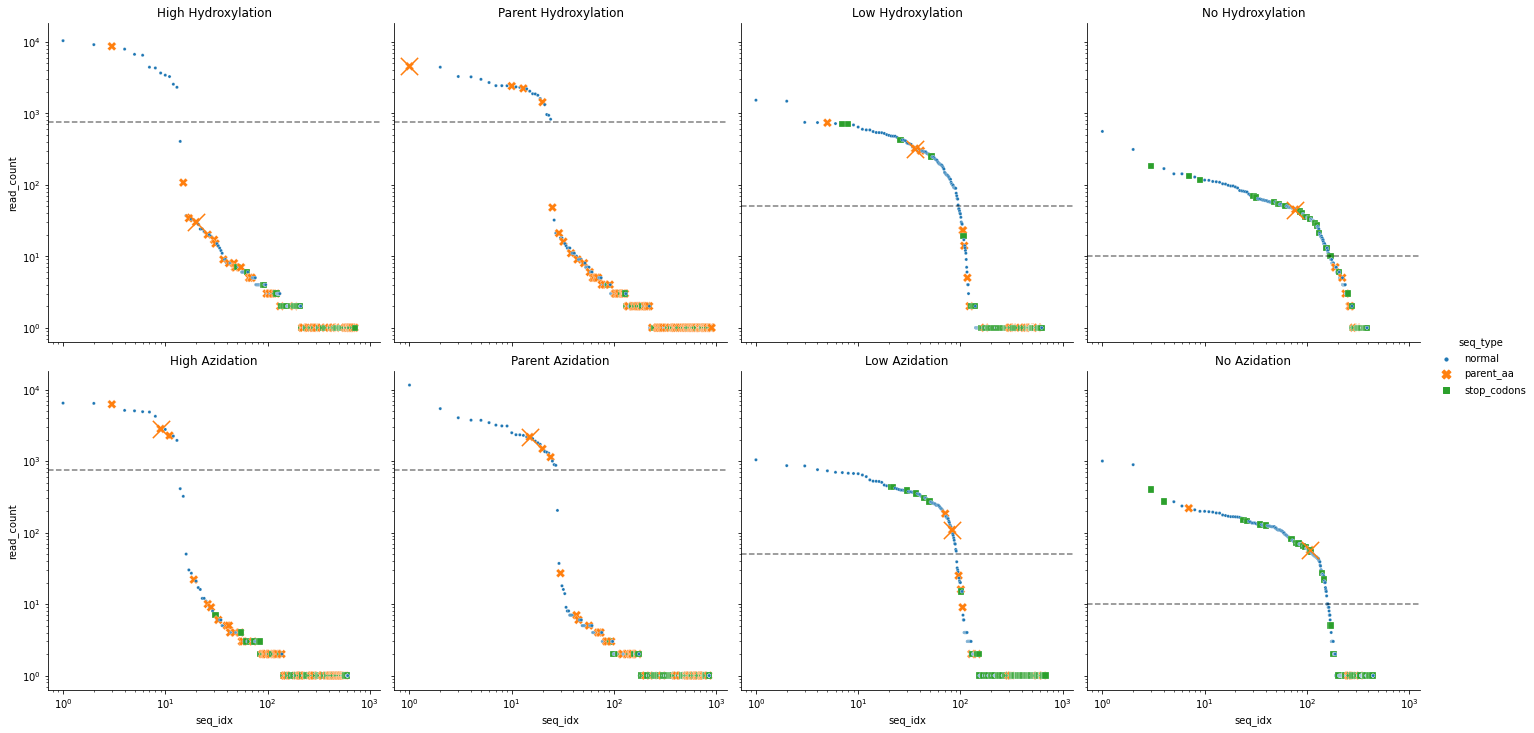

In [10]:
grid = sns.relplot(data=df, x="seq_idx", y="read_count", 
                    style="seq_type", hue="seq_type", 
                    size="seq_type", 
                    sizes={"normal":10, "parent_aa":80, "stop_codons":80},
                    col="bin_num", col_wrap=4)
grid.set(xscale="log", yscale="log")
for bin_num, ax in grid.axes_dict.items():      
    df_wt_bin = df_wt[df_wt.bin_num == bin_num]
    ax.set_title(sample_info.category[sample_info.bin_num == bin_num].item())
    ax.scatter(df_wt_bin.seq_idx, df_wt_bin.read_count, marker="x", 
               s=300, color="tab:orange")
    ax.axhline(cutoffs[bin_num], linestyle="--", color="black", alpha=0.5)
    
plt.savefig("../output/2D/preprocessing_stats.png", dpi=300)
pass

* Hydroxylation (bins 1-4)
  * Parent 2D appears dominant in bin 2 (Parent Hydroxylation) only and not in other bins. 
* Azidization (Bins 5-8)
  * Parent 2D doesn't stand out in any bin. Looks best in Bin 5 (High Azidation).

In [11]:
sample_info["num_reads"] = np.zeros(len(sample_info), dtype=int)
sample_info["num_unique"] = np.zeros(len(sample_info), dtype=int)
sample_info["WT_rank"] = np.zeros(len(sample_info), dtype=int) * -1
sample_info["WT_pct"] = np.zeros(len(sample_info), dtype=int)

In [12]:
df_by_bin = df.groupby("bin_num")
for bin_num, bin_data in df_by_bin:
    bin_mask = (sample_info.bin_num == bin_num)
    num_reads = bin_data.read_count.sum()
    sample_info.loc[bin_mask, "num_reads"] = num_reads
    sample_info.loc[bin_mask, "num_unique"] = len(bin_data)
    bin_wt = bin_data[bin_data.is_wt == True]
    sample_info.loc[bin_mask, "WT_rank"] = int(bin_wt.seq_idx.item())
    sample_info.loc[bin_mask, "WT_pct"] = int(bin_wt.read_count.item() / num_reads * 100)

In [13]:
sample_info # cutoffs

,bin_num,bin_name,category,num_samples,response,num_reads,num_unique,WT_rank,WT_pct
0,1,2D-R1-B1,High Hydroxylation,14,3,74963,714,20,0
1,2,2D-R1-B2,Parent Hydroxylation,25,2,55970,900,1,8
2,3,2D-R1-B3,Low Hydroxylation,186,1,32457,623,36,0
3,4,2D-R1-B4,No Hydroxylation,675,0,9377,388,77,0
4,5,2D-R1-B5,High Azidation,16,3,57018,609,9,4
5,6,2D-R1-B6,Parent Azidation,27,2,73299,855,15,2
6,7,2D-R1-B7,Low Azidation,174,1,31568,680,83,0
7,8,2D-R1-B8,No Azidation,683,0,16263,446,107,0


* The *No Hydroxylation* and *No Azidization* groups have the largest number of samples but the smallest number of total reads. **Why?** 

### Add cutoffs

In [14]:
df_cutoff = pd.concat([bin_data[bin_data.read_count >= cutoffs[bin_num]] 
                       for bin_num, bin_data in df_by_bin])

### Save cutoff dataframe for further processing

# convert bin number 1-8 to response code
df_cutoff["response"] = sample_info.response.to_numpy()[df_cutoff.bin_num.to_numpy() - 1] 
df_cutoff

,seq_idx,sequence,read_count,bin_num,count_frac_bin,is_wt,sequence_aa,is_wt_aa,first_stop,is_trunc,is_not_trunc,seq_type,response
0,1,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,10336,1,0.137881,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,3
1,2,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,9102,1,0.121420,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,3
2,3,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,8612,1,0.114883,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,False,True,parent_aa,3
3,4,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,7872,1,0.105012,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADKADAIVMDIVPDG...,False,273,False,True,normal,3
4,5,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGCCACCGCAG...,6654,1,0.088764,False,MQHTYPAQLMRFATAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4925,157,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGTACCGCAG...,10,8,0.000615,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,0
4926,158,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,10,8,0.000615,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,0
4927,159,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTAGGCGCCGCAG...,10,8,0.000615,False,MQHTYPAQLMRLGAAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,0
4928,160,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,10,8,0.000615,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMYIVPDG...,False,273,False,True,normal,0


In [15]:
df_cutoff_bin = df_cutoff.groupby('bin_num')
print("Cutoff dataframe stats")
pd.concat([sample_info.groupby("bin_num").num_samples.first(),
         df_cutoff_bin.read_count.count(),
         df_cutoff_bin.is_wt.sum(),
         df_cutoff_bin.is_wt_aa.sum(),
         df_cutoff_bin.is_trunc.sum()], axis=1)

Cutoff dataframe stats


,num_samples,read_count,is_wt,is_wt_aa,is_trunc
bin_num,,,,,
1,14,13,0,1,0
2,25,24,1,4,0
3,186,95,1,3,4
4,675,171,1,1,22
5,16,13,1,3,0
6,27,27,1,3,0
7,174,91,1,2,6
8,683,161,1,2,15


In [16]:
df_hydroxy = df_cutoff[df_cutoff.bin_num.isin([1,2,3,4])].copy()
df_azid = df_cutoff[df_cutoff.bin_num.isin([5,6,7,8])].copy()

In [17]:
df_hydroxy.to_pickle(f"{bin_dir}/hydroxy.pkl")
df_azid.to_pickle(f"{bin_dir}/azid.pkl")

In [18]:
df_azid.head()

,seq_idx,sequence,read_count,bin_num,count_frac_bin,is_wt,sequence_aa,is_wt_aa,first_stop,is_trunc,is_not_trunc,seq_type,response
2625,1,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,6459,5,0.113280,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,3
2626,2,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,6401,5,0.112263,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,3
2627,3,ATGCAGCATACCTATCCGGCTCAGCTGATGCGTTTTGGCACCGCGG...,6222,5,0.109123,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,False,True,parent_aa,3
2628,4,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,5110,5,0.089621,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,3
2629,5,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,5039,5,0.088376,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,3
